In [1]:
import control as ct
from control.matlab import *

<TransferFunction>: sys[4]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


126.6 s + 0.335
---------------
     378 s

<TransferFunction>: loop PI Shins 2001
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


    -2533 s^4 + 297.2 s^3 - 14.39 s^2 + 0.2637 s + 0.000804
---------------------------------------------------------------
3.78e+05 s^5 + 4.574e+04 s^4 + 2313 s^3 + 47.63 s^2 + 0.04536 s

<TransferFunction>: sys[12]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


5445 s^2 + 108.9 s + 0.4445
---------------------------
     1225 s^2 + 175 s

<TransferFunction>: sys[20]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


6750 s^2 + 135 s + 0.375
------------------------
    1800 s^2 + 300 s

G0 bandwidth:  0.0009976283442501993 clsd PI bandwidth:  0.016215738883337733 clsd2 PID bandwidth 0.035510912166378084 clsd3 PID tuned bandwidth:  0.031461134426019825
PI margin:  (2.1493066458891334, 36.97723694831225, 0.014600623847540928, 0.007081956742974608) PID margin:  (1.323035491875038, 33.15208666189827

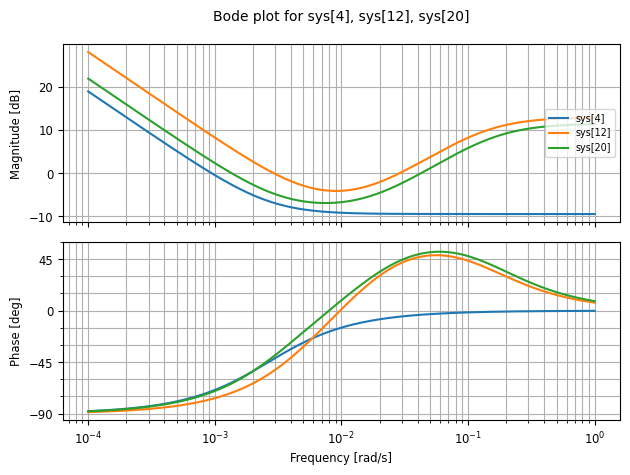

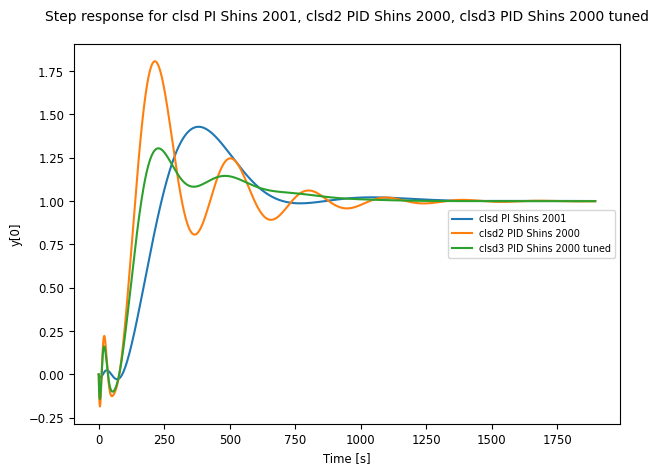

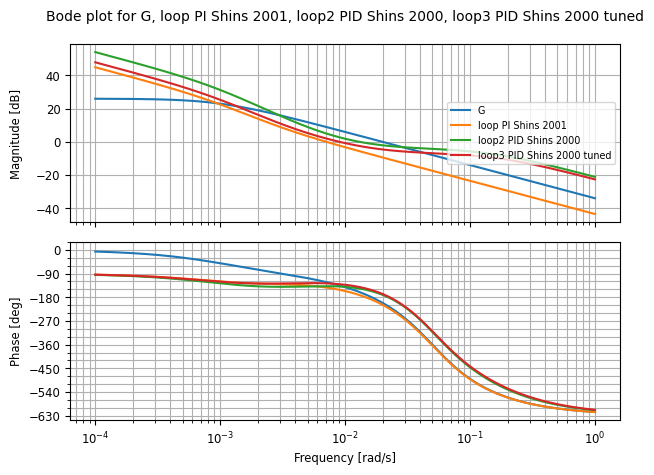

In [2]:
#Gm
taod = 100; Tm = 1000; Km = 20;
G0 = ct.tf(Km, [Tm, 1], name = "G0"); [delay_num, delay_den] = ct.pade(taod, 3); Pade_delay = ct.tf(delay_num, delay_den); G = ct.series(G0, Pade_delay, name="G")
#PI Shinsky 2001
Kc = Tm/(Km*taod)*0.67; Ti = 3.78 * taod; K = Kc + ct.tf(Kc, [Ti, 0]); print(K)
loop = ct.series(K,G, name="loop PI Shins 2001"); print(loop);
clsd = ct.feedback (loop, 1, sign = -1, name="clsd PI Shins 2001"); 

#PID Shinsky 2000
Kc = 0.889*Tm/(Km*taod); Ti = 1.75*taod; Td = 0.7*taod; K2 = (Kc + ct.tf(Kc, [Ti, 0])) * (ct.tf([Td, 1], [0.1*Td, 1])); print(K2);
loop2 = ct.series(K2, G, name="loop2 PID Shins 2000"); clsd2 = ct.feedback(loop2, 1, sign=-1, name="clsd2 PID Shins 2000"); 

#PID Shinsky 2000, tuned
Kc = 0.75*Tm/(Km*taod); Ti = 3*taod; Td = 0.6*taod; K3 = (Kc + ct.tf(Kc, [Ti, 0])) * (ct.tf([Td, 1], [0.1*Td, 1])); print(K3); ct.bode([K, K2, K3]);
loop3 = ct.series(K3, G, name="loop3 PID Shins 2000 tuned"); clsd3 = ct.feedback(loop3, 1, sign=-1, name="clsd3 PID Shins 2000 tuned"); 

#compare step_response and bode plots
ct.step_response([clsd, clsd2, clsd3]).plot();
ct.bode([G, loop, loop2, loop3])

#compare bandwidth
print("G0 bandwidth: ", bandwidth(G0), "clsd PI bandwidth: ", bandwidth(clsd), "clsd2 PID bandwidth", bandwidth(clsd2), "clsd3 PID tuned bandwidth: ", bandwidth(clsd3))
#compare margin
print("PI margin: ", margin(loop), "PID margin: ", margin(loop2), "PID tuned margin: ", margin(loop3))
                                                                                    

<TransferFunction>: sys[2193]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


161.5 s + 0.475
---------------
     340 s

<TransferFunction>: loop PI Shins 1996
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


   -3230 s^4 + 378.1 s^3 - 18.24 s^2 + 0.3306 s + 0.00114
-------------------------------------------------------------
3.4e+05 s^5 + 4.114e+04 s^4 + 2081 s^3 + 42.84 s^2 + 0.0408 s

<TransferFunction>: sys[2201]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


3569 s^2 + 93.6 s + 0.48
------------------------
   743.6 s^2 + 143 s

<TransferFunction>: sys[2209]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


8364 s^2 + 164 s + 0.41
-----------------------
   2040 s^2 + 340 s

G0 bandwidth:  0.0009976283442501993 clsd PI bandwidth:  0.02053788680461991 clsd2 PID bandwidth 0.03254808443728555 clsd3 PID tuned bandwidth:  0.03307973248679075
PI margin:  (1.4872597567228605, 22.675035432303815, 0.014386497707431101, 0.009862846226074697) PID margin:  (1.3639517366463283, 21.58684832050446, 0.019802

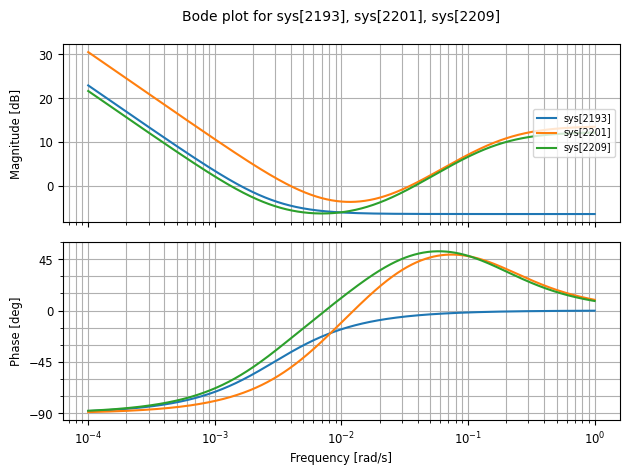

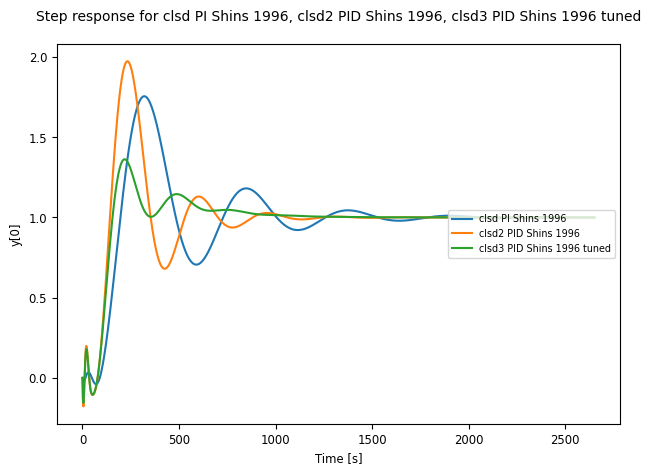

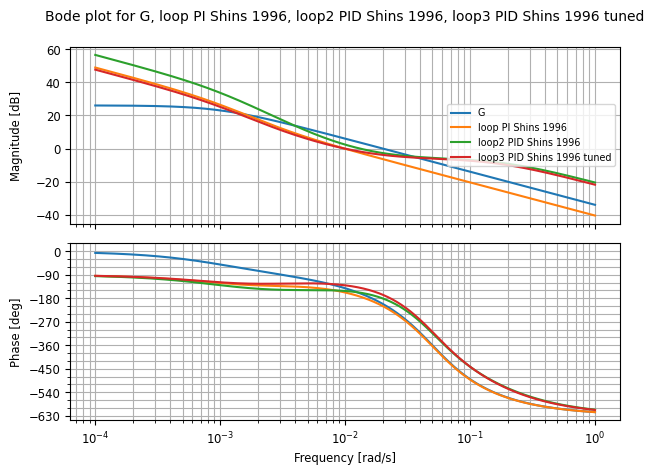

In [85]:
#Gm
taod = 100; Tm = 1000; Km = 20;
G0 = ct.tf(Km, [Tm, 1], name = "G0"); [delay_num, delay_den] = ct.pade(taod, 3); Pade_delay = ct.tf(delay_num, delay_den); G = ct.series(G0, Pade_delay, name="G")
#PI Shinsky 1996
Kc = Tm/(Km*taod)*0.95; Ti = 3.4 * taod; K = Kc + ct.tf(Kc, [Ti, 0]); print(K)
loop = ct.series(K,G, name="loop PI Shins 1996"); print(loop);
clsd = ct.feedback (loop, 1, sign = -1, name="clsd PI Shins 1996"); 

#PID Shinsky 1996
Kc = 0.96*Tm/(Km*taod); Ti = 1.43*taod; Td = 0.52*taod; K2 = (Kc + ct.tf(Kc, [Ti, 0])) * (ct.tf([Td, 1], [0.1*Td, 1])); print(K2);
loop2 = ct.series(K2, G, name="loop2 PID Shins 1996"); clsd2 = ct.feedback(loop2, 1, sign=-1, name="clsd2 PID Shins 1996"); 

#PID Shinsky 1996, tuned
Kc = 0.82*Tm/(Km*taod); Ti = 3.4*taod; Td = 0.6*taod; K3 = (Kc + ct.tf(Kc, [Ti, 0])) * (ct.tf([Td, 1], [0.1*Td, 1])); print(K3); ct.bode([K, K2, K3]);
loop3 = ct.series(K3, G, name="loop3 PID Shins 1996 tuned"); clsd3 = ct.feedback(loop3, 1, sign=-1, name="clsd3 PID Shins 1996 tuned"); 

#compare step_response and bode plots
ct.step_response([clsd, clsd2, clsd3]).plot();
ct.bode([G, loop, loop2, loop3])

#compare bandwidth
print("G0 bandwidth: ", bandwidth(G0), "clsd PI bandwidth: ", bandwidth(clsd), "clsd2 PID bandwidth", bandwidth(clsd2), "clsd3 PID tuned bandwidth: ", bandwidth(clsd3))
#compare margin
print("PI margin: ", margin(loop), "PID margin: ", margin(loop2), "PID tuned margin: ", margin(loop3))

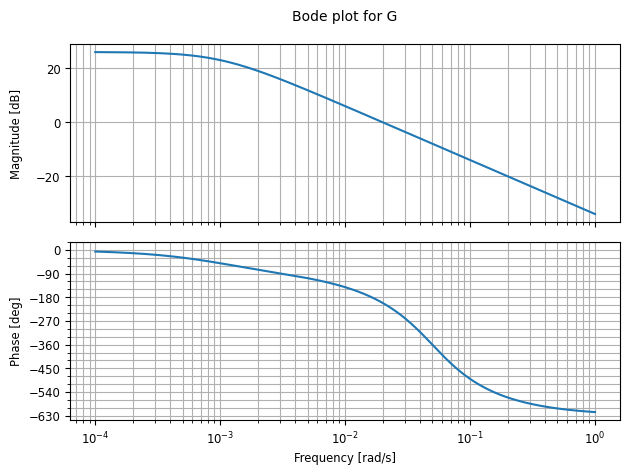

In [2]:
taod = 100; Tm = 1000; Km = 20;
G0 = ct.tf(Km, [Tm, 1], name = "G0"); [delay_num, delay_den] = ct.pade(taod, 3); Pade_delay = ct.tf(delay_num, delay_den); G = ct.series(G0, Pade_delay, name="G")
ct.bode(G)

<TransferFunction>: sys[9]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


112.5 s + 0.375
---------------
     300 s

0.375


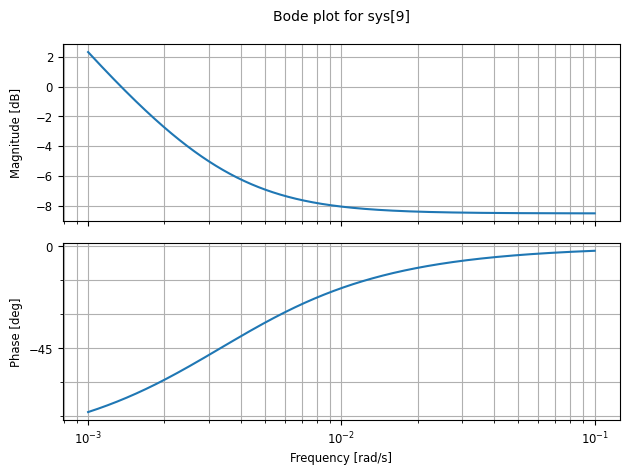

In [4]:
#TI shinksy 2001 bode
Kc = Tm/(Km*taod)*0.75; Ti = 3 * taod; K = Kc + ct.tf(Kc, [Ti, 0]); print(K)
ct.bode(K); print(Kc)


<TransferFunction>: Loop - PI 
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


    -2533 s^4 + 297.2 s^3 - 14.39 s^2 + 0.2637 s + 0.000804
---------------------------------------------------------------
3.78e+05 s^5 + 4.574e+04 s^4 + 2313 s^3 + 47.63 s^2 + 0.04536 s



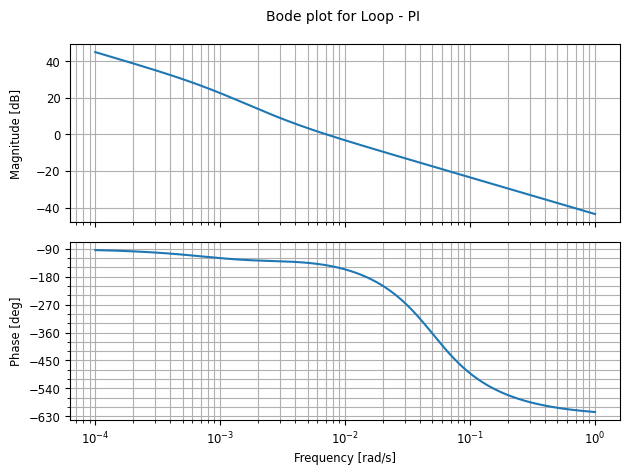

In [10]:
#loop bode with PI on G
loop = ct.series(K,G, name="Loop - PI "); print(loop);
ct.bode(loop)

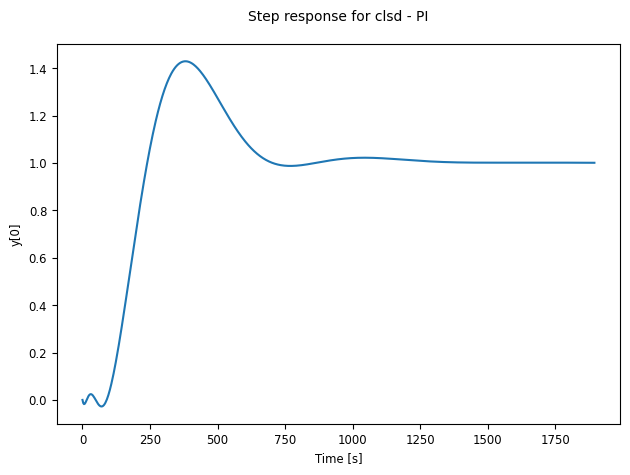

In [7]:
#PI closed-loop response
clsd = ct.feedback (loop, 1, sign = -1, name="clsd - PI"); 
ct.step_response(clsd).plot()


<TransferFunction>: sys[49]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


6750 s^2 + 135 s + 0.375
------------------------
    1800 s^2 + 300 s



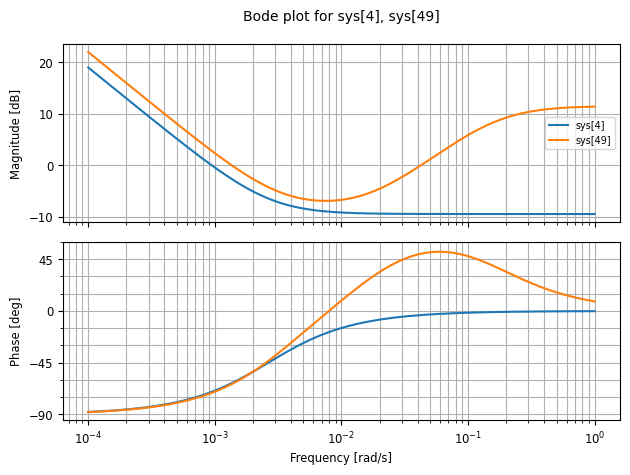

In [5]:
#PID Shinsky 2000, tuned
Kc = 0.75*Tm/(Km*taod); Ti = 3*taod; Td = 0.6*taod; K3 = (Kc + ct.tf(Kc, [Ti, 0])) * (ct.tf([Td, 1], [0.1*Td, 1])); print(K3); ct.bode([K, K3]);
loop3 = ct.series(K3, G, name="loop - PID"); clsd3 = ct.feedback(loop3, 1, sign=-1, name="clsd - PID "); 

In [8]:
print(1/60)

0.016666666666666666


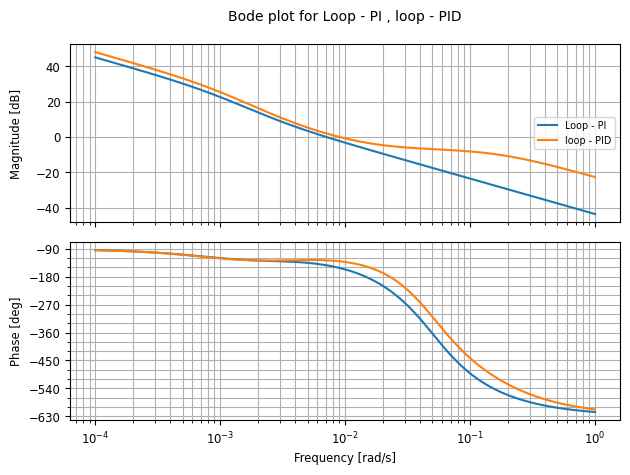

In [11]:
ct.bode([loop, loop3])

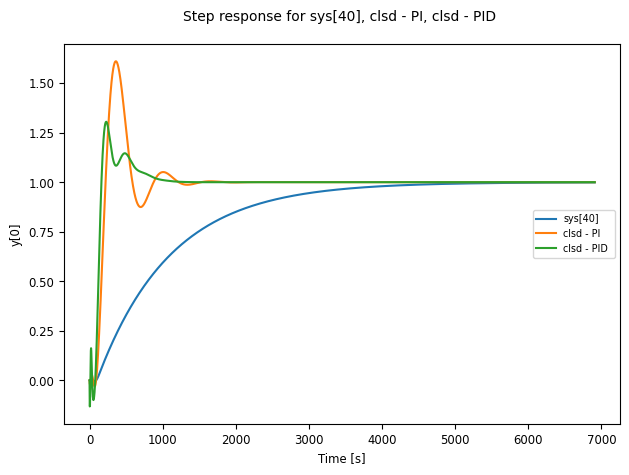

In [12]:
ct.step_response([0.05*G, clsd, clsd3]).plot()


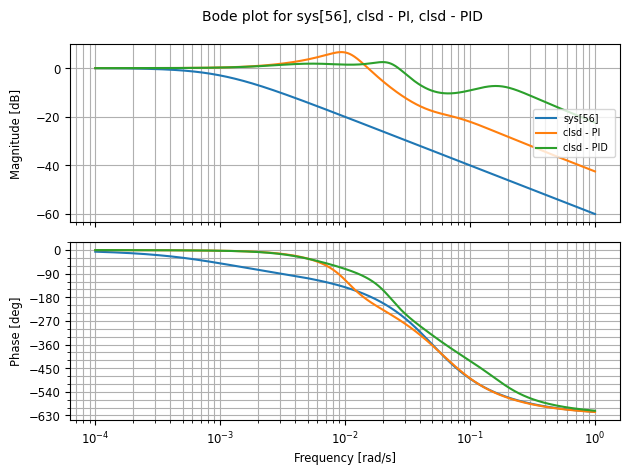

In [16]:
ct.bode([0.05*G, clsd, clsd3])

<TransferFunction>: sys[206]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


1.215e+04 s^2 + 175.5 s + 0.45
------------------------------
       2700 s^2 + 300 s



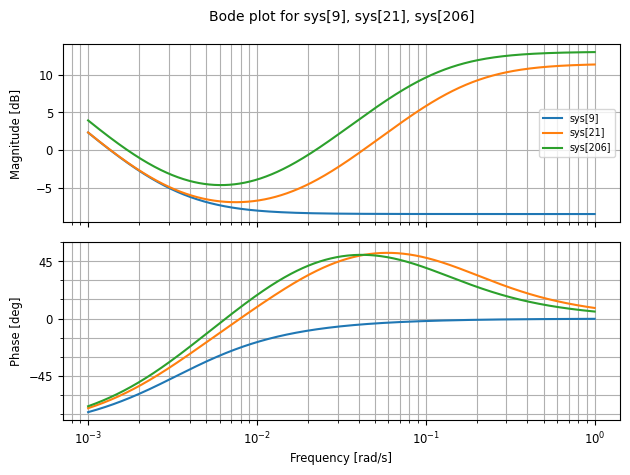

In [34]:
#PID Shinsky 2000, tuned
Kc = 0.9*Tm/(Km*taod); Ti2 = 3*taod; Td2 = 0.9*taod; K4 = (Kc + ct.tf(Kc, [Ti2, 0])) * (ct.tf([Td2, 1], [0.1*Td2, 1])); print(K4); ct.bode([K, K3, K4]);
loop4 = ct.series(K4, G, name="loop - PID2"); clsd4 = ct.feedback(loop4, 1, sign=-1, name="clsd - PID2 "); 

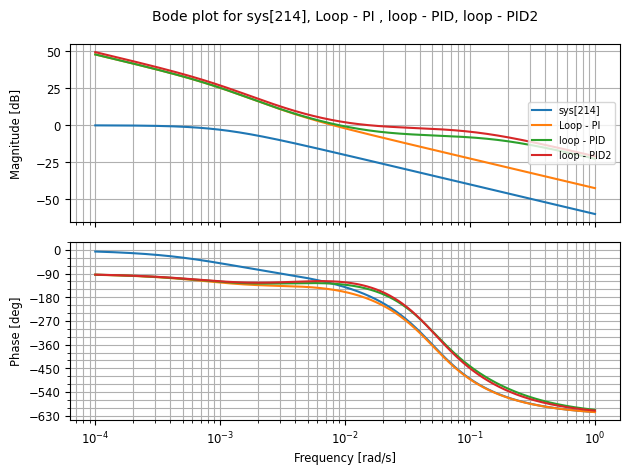

In [35]:
ct.bode([0.05*G, loop, loop3, loop4])

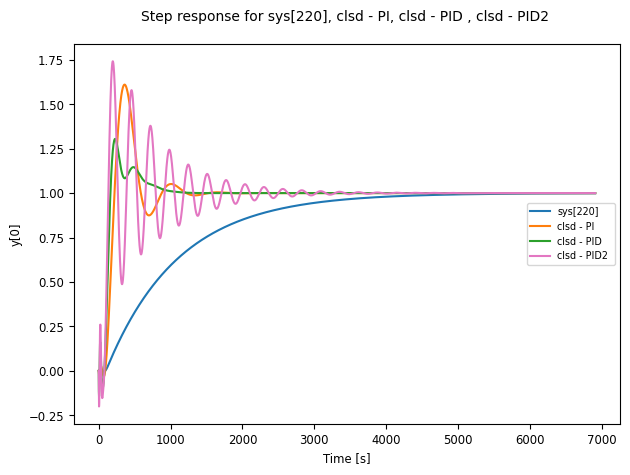

In [36]:
ct.step_response([0.05*G, clsd, clsd3, clsd4]).plot()

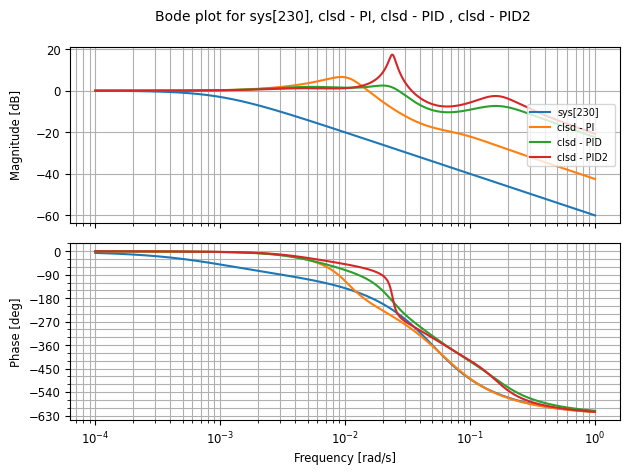

In [37]:
ct.bode([0.05*G, clsd, clsd3, clsd4])

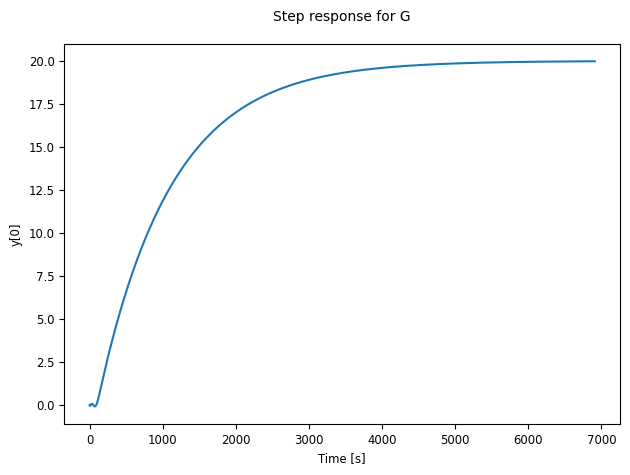

In [3]:
ct.step_response(G).plot()